# Compute ACFs
Compute
$$
C_u(t) = \frac{\langle \delta u(0)\delta u(t)\rangle}{\langle \delta u(0)^2\rangle} \quad t\in[0, T]
$$
with $u$ = 
1. $s_1 = \psi_1(x)$
2. $s_2 = \psi_2(x)$
3. diheral, $\phi$
4. diheral, $\psi$

Rules of Thumb for procecss with timescale $\tau_u$ (we are computing it, but I've written in into the exponential as the "true" timescale):
$$
\tau_u = \int_0^\infty dt\, e^{-t/\tau_u} 
\approx \int_0^{c\tau_u} dt\, e^{-t/\tau_u}
$$
1. Sokal window constant (c) = how many timescales out to capture this integral.  Sweet spot = 5 where 99.3% of the ACF is captured.  There is a bias-variance tradeoff.
2. ACF horizon
$$
T \ge 2c\tau_u \quad \textrm{go to 15 ns }\approx 10\tau_1
$$

## Load unbiased dataset

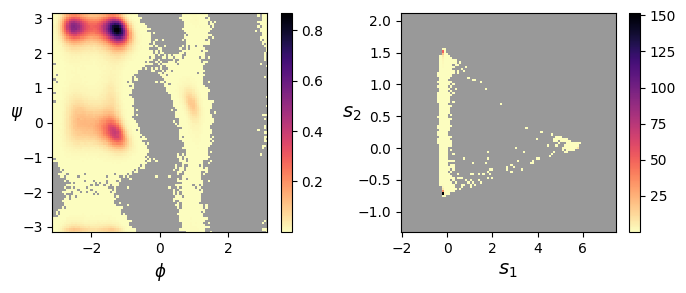

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from src.data import simulation_data
from src.param import param_unbiased_reference
from src.plots import plot_dihedrals_hist2d, plot_cvs_hist2d

p = param_unbiased_reference()
sd = simulation_data(p)

fig, axs = plt.subplots(1, 2, figsize=(7, 3))
plot_dihedrals_hist2d(fig, axs[0], sd.dihedrals_pdf)
plot_cvs_hist2d(fig, axs[1], sd.cvs_pdf)
fig.tight_layout()

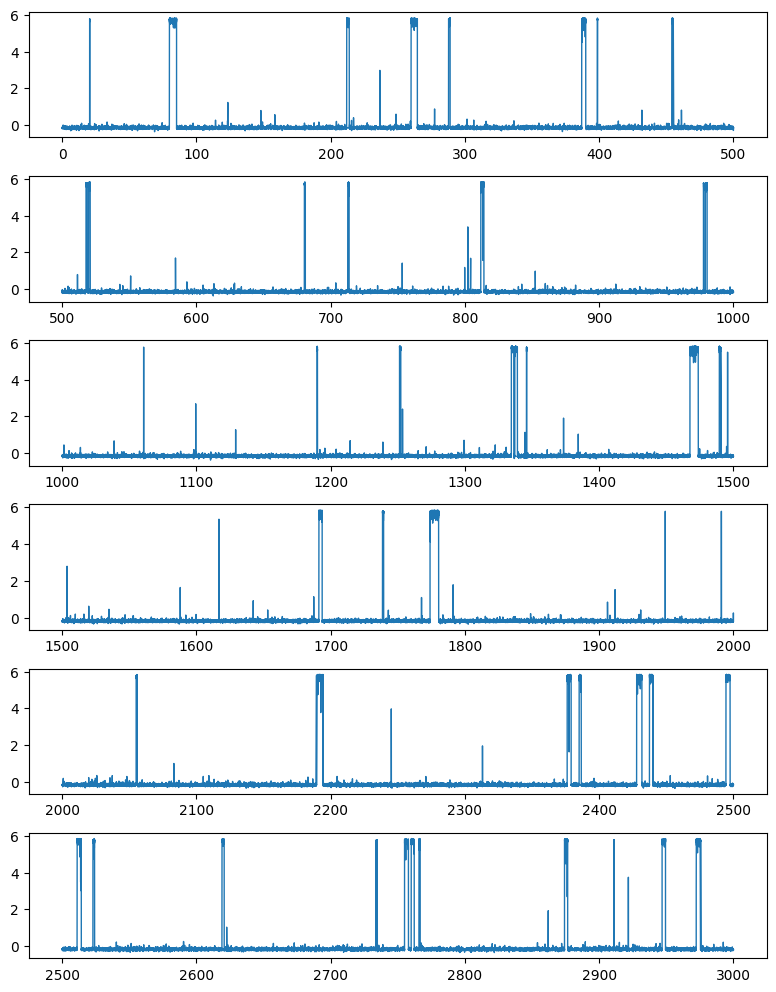

In [2]:
import importlib
import openmm.unit as unit
import src.util

importlib.reload(src.util)

from src.util import chunk_iter

ns = np.arange(len(sd.cvs)) * p.lagtime / unit.nanosecond
lagtime = p.lagtime / unit.picosecond

num_chunks = 6
titer = chunk_iter(ns, num_chunks)
uiter = chunk_iter(sd.cvs[:, 0], num_chunks)

fig, axs = plt.subplots(num_chunks, 1, figsize=(8, 10))
for t, u, ax in zip(titer, uiter, axs):
    ax.plot(t, u, lw=1)
fig.tight_layout()

In [3]:
print(sd.timescales)

[1.25255696e+03 6.11525847e+01 2.63525642e+01 2.30529580e+00
 1.52031536e+00 1.16611866e+00]


## Compute the ACFs

In [4]:
import openmm.unit as unit
from src.acf import compute_acf
from src.dataclass import DataClass, data_class
from src.util import save_pickle, load_pickle


def compute_acfs(wd, signals, lagtime, num_frames_acf, calculate=True):
    file = wd / "acfs.pickle"
    if calculate:
        acfs = {
            label: compute_acf_dataclass(u, lagtime, num_frames_acf)
            for label, u in signals.items()
        }
        save_pickle(file, acfs)
    else:
        acfs = load_pickle(file)
    return acfs


def compute_acf_dataclass(*args, **kwargs):
    tau, ct, info = compute_acf(*args, **kwargs)
    return DataClass(
        tau=tau,
        ct=ct,
        c0=info["c0"],
        window=info["window"],
        tau_int_frames=info["tau_int_frames"],
        imag=info["imag"],
    )


ns = np.arange(len(sd.cvs)) * p.lagtime / unit.nanosecond
lagtime = p.lagtime / unit.picosecond
num_frames_acf = 80_000  # 10 ns, too short, but similar to befoe
acf = compute_acf_dataclass(sd.cvs[:, 0], lagtime, num_frames_acf)

# signals = {
#     r"$\psi_1(x)$": sd.cvs[:, 0],
#     r"$\psi_2(x)$": sd.cvs[:, 1],
#     r"$\phi$": sd.dihedrals[:, 0],
#     r"$\psi$": sd.dihedrals[:, 1],
# }
# acfs = compute_acfs(sd.working_dir, signals, lagtime, num_frames_acf, calculate=False)

# num_frames = num_frames_acf
# fig, ax = plt.subplots(1, 1, figsize=(7, 3))
# for label, acf in acfs.items():
#     ax.plot(
#         ns[:num_frames],
#         acf.ct[:num_frames],
#         alpha=0.4,
#         lw=2,
#         label=rf"{label}, $\tau_\mathrm{{int}}$={acf.tau:.0f} ps",
#     )
# ax.set_xlabel(r"$\tau$ (ns)")
# ax.set_ylabel(r"$C(\tau)$")
# ax.legend();

Text(0, 0.5, 'C($\\tau$)')

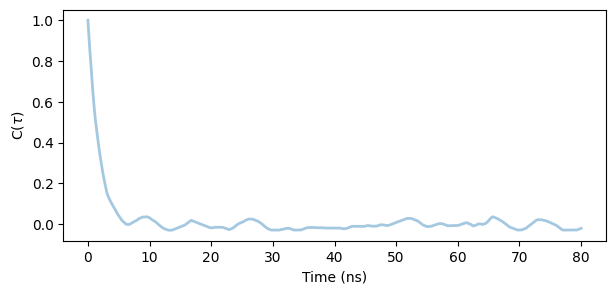

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(ns[:num_frames_acf], acf.ct, lw=2, alpha=0.4)
ax.set_xlabel("Time (ns)")
ax.set_ylabel(r"C($\tau$)")

Text(0, 0.5, '$\\theta(\\tau)$')

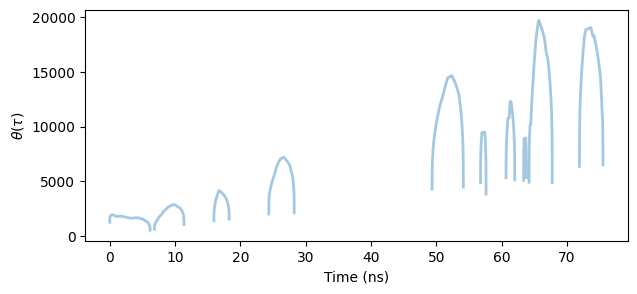

In [ ]:
from src.acf import compute_theta

theta = compute_theta(acf.ct, lagtime)

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(ns[:num_frames_acf], theta, lw=2, alpha=0.4)
ax.set_xlabel("Time (ns)")
ax.set_ylabel(r"$\theta(\tau)$")

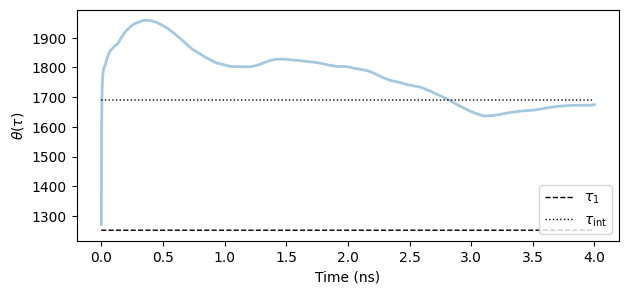

In [ ]:
num_frames = 4000

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(ns[:num_frames], theta[:num_frames], lw=2, alpha=0.4)
ax.plot(
    ns[:num_frames],
    np.full(num_frames, sd.timescales[0]),
    lw=1,
    c="black",
    ls="--",
    label=r"$\tau_1$",
)
ax.plot(
    ns[:num_frames],
    np.full(num_frames, acf.tau),
    lw=1,
    c="black",
    ls=":",
    label=r"$\tau_\mathrm{int}$",
)
ax.set_xlabel("Time (ns)")
ax.set_ylabel(r"$\theta(\tau)$")
ax.legend(loc=4)

1690.5174926942059

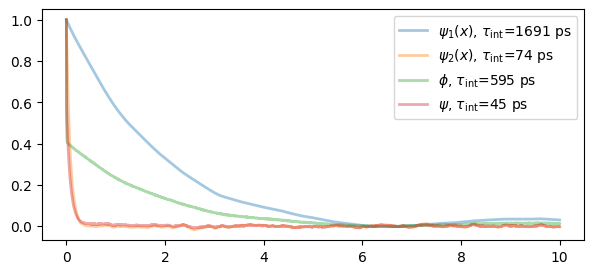

In [28]:
num_frames = 10_000

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
for label, acf in acfs.items():
    ax.plot(
        ns[:num_frames],
        acf.ct[:num_frames],
        alpha=0.4,
        lw=2,
        label=rf"{label}, $\tau_\mathrm{{int}}$={acf.tau:.0f} ps",
    )
ax.legend()

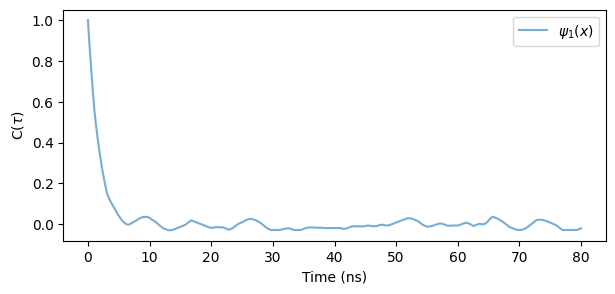

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
for label, acf in acfs.items():
    ax.plot(ns[: len(acf.ct)], acf.ct, alpha=0.6, label=label)
    break
ax.set_xlabel("Time (ns)")
ax.set_ylabel(r"C($\tau$)")
ax.legend()

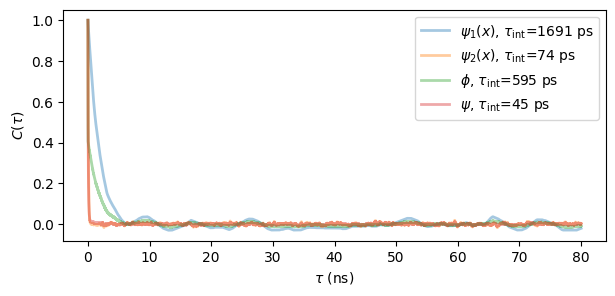

In [32]:
from src.param import param_unbiased_weighted

p = param_unbiased_weighted()
sd = simulation_data(p)

ns = np.arange(len(sd.cvs)) * p.lagtime / unit.nanosecond
lagtime = p.lagtime / unit.picosecond
num_frames_acf = 80_000  # 10 ns, too short, but similar to befoe
signals = {
    r"$\psi_1(x)$": sd.cvs[:, 0],
    r"$\psi_2(x)$": sd.cvs[:, 1],
    r"$\phi$": sd.dihedrals[:, 0],
    r"$\psi$": sd.dihedrals[:, 1],
}
acfs = compute_acfs(sd.working_dir, signals, lagtime, num_frames_acf, calculate=True)

num_frames = num_frames_acf
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
for label, acf in acfs.items():
    ax.plot(
        ns[:num_frames],
        acf.ct[:num_frames],
        alpha=0.4,
        lw=2,
        label=rf"{label}, $\tau_\mathrm{{int}}$={acf.tau:.0f} ps",
    )
ax.set_xlabel(r"$\tau$ (ns)")
ax.set_ylabel(r"$C(\tau)$")
ax.legend()

In [33]:
sd.working_dir

PosixPath('data/verify-weighted')

In [1]:
# fig, axs = plt.subplots(1, 2, figsize=(7, 3))
# fig, ax = plt.subplots(1, 1, figsize=(4, 3))
# ax.plot(ns, ct)

In [ ]:
from src.acf import compute_acf_with_errors  # the patched module

# --- settings -------------------------------------------------------------
LAGTIME = sd.lagtime  # time between frames (ps)
NUM_FRAMES_ACF = 80_000  # how many frames to compute?
NUM_BLOCKS = 8  # contiguous blocks -> standard error of the mean

cvs = (
    dict(label="CV1", u=sd.cvs[:, 0], kind="linear"),
    dict(label="CV2", u=sd.cvs[:, 1], kind="linear"),
    dict(label=r"\phi", u=sd.dihedrals[:, 0], kind="circular"),
    dict(label=r"\psi", u=sd.dihedrals[:, 1], kind="circular"),
)
tau, ct, info = compute_acf(sd.cvs[:, 0], LAGTIME, NUM_FRAMES_ACF)
ns = np.arange(len(ct)) * LAGTIME

np.float64(202.8620991233047)

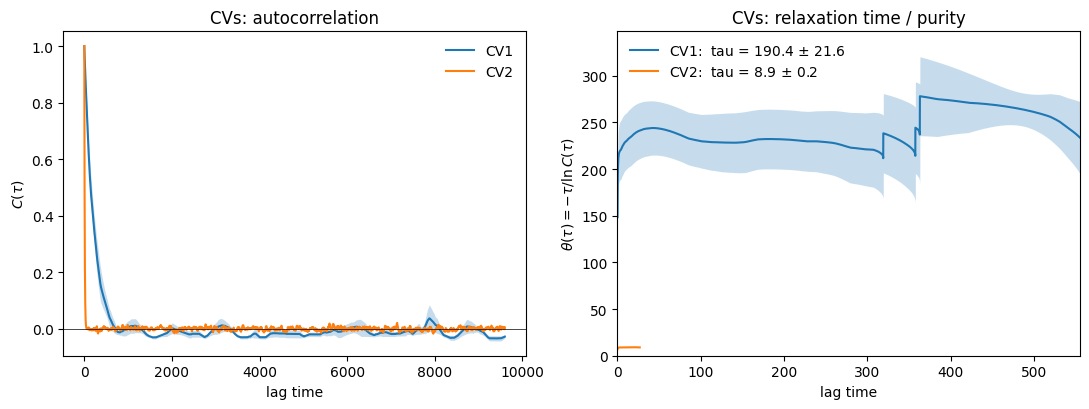

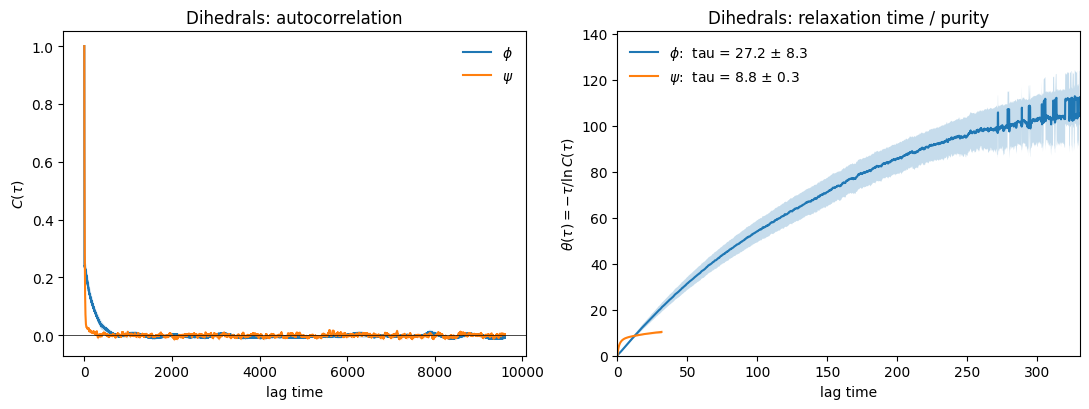

   CV1:  tau =   190.37 +/- 21.60
   CV2:  tau =     8.89 +/- 0.23
$\phi$:  tau =    27.16 +/- 8.30
$\psi$:  tau =     8.80 +/- 0.28


In [ ]:
from src.acf import compute_acf_with_errors  # the patched module

# --- settings -------------------------------------------------------------
LAGTIME = sd.lagtime  # time between frames (ps)
NUM_FRAMES_ACF = 80_000  # how many lags to compute
NUM_BLOCKS = 8  # contiguous blocks -> standard error of the mean


def analyze(
    signals,
    kind,
    title,
    lagtime=LAGTIME,
    num_frames_acf=NUM_FRAMES_ACF,
    num_blocks=NUM_BLOCKS,
    c_floor=0.05,
):
    """Blocked ACF / theta analysis on {label: trajectory}, with a 2-panel plot.

    signals : dict {label: 1-D array}.  For kind='circular' the arrays are
              angles in *radians*.
    kind    : 'linear' (unbounded CVs) or 'circular' (dihedrals).
    c_floor : only show theta while C(tau) > c_floor; past that the ACF is noise
              and theta = -tau/ln C diverges meaninglessly.
    """
    results = {
        lab: compute_acf_with_errors(
            u, lagtime, num_frames_acf, num_blocks=num_blocks, kind=kind
        )
        for lab, u in signals.items()
    }

    fig, (axC, axT) = plt.subplots(1, 2, figsize=(11, 4.2))
    colors = plt.cm.tab10.colors
    th_vals, xmax = [], 0.0

    for (label, r), c in zip(results.items(), colors):
        t = r["time"]
        # C(tau) with +/- 1 SEM band
        axC.plot(t, r["ct_mean"], color=c, lw=1.5, label=label)
        axC.fill_between(
            t,
            r["ct_mean"] - r["ct_err"],
            r["ct_mean"] + r["ct_err"],
            color=c,
            alpha=0.25,
            lw=0,
        )
        # theta(tau) with +/- 1 SEM band, restricted to where C > c_floor
        ok = np.isfinite(r["theta_mean"]) & (r["ct_mean"] > c_floor)
        th = np.where(ok, r["theta_mean"], np.nan)
        the = np.where(ok, r["theta_err"], np.nan)
        axT.plot(
            t,
            th,
            color=c,
            lw=1.5,
            label=f"{label}:  tau = {r['tau_mean']:.1f} $\\pm$ {r['tau_err']:.1f}",
        )
        axT.fill_between(t, th - the, th + the, color=c, alpha=0.25, lw=0)
        if ok.any():
            th_vals.append(th[ok])
            xmax = max(xmax, t[ok].max())

    axC.axhline(0, color="k", lw=0.5)
    axC.set_xlabel("lag time")
    axC.set_ylabel(r"$C(\tau)$")
    axC.set_title(f"{title}: autocorrelation")
    axC.legend(frameon=False)
    axT.set_xlabel("lag time")
    axT.set_ylabel(r"$\theta(\tau) = -\tau/\ln C(\tau)$")
    axT.set_title(f"{title}: relaxation time / purity")
    axT.legend(frameon=False)
    if th_vals:
        axT.set_xlim(0, xmax)
        axT.set_ylim(0, 1.25 * np.nanmax(np.concatenate(th_vals)))
    fig.tight_layout()
    return fig, results


# 1-2.  Linear CVs:  CV1 = sd.cvs[:, 0], CV2 = sd.cvs[:, 1] -------------------
cv_signals = {"CV1": sd.cvs[:, 0], "CV2": sd.cvs[:, 1]}
fig_cv, res_cv = analyze(cv_signals, kind="linear", title="CVs")
fig_cv.savefig("acf_cvs.png", dpi=150)

# 3.  Dihedrals (circular):  phi, psi  -- MUST be radians --------------------
phi, psi = sd.dihedrals[:, 0], sd.dihedrals[:, 1]
# if your dihedrals are in degrees, convert first:
# phi, psi = np.deg2rad(phi), np.deg2rad(psi)
dih_signals = {r"$\phi$": phi, r"$\psi$": psi}
fig_dih, res_dih = analyze(dih_signals, kind="circular", title="Dihedrals")
fig_dih.savefig("acf_dihedrals.png", dpi=150)

plt.show()

for name, r in {**res_cv, **res_dih}.items():
    print(f"{name:>6}:  tau = {r['tau_mean']:8.2f} +/- {r['tau_err']:.2f}")